In [ ]:
import ee
import geemap

# Initialize Earth Engine
try:
    ee.Initialize(project="desertification-risk")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project="desertification-risk")

print("[*] Fetching Hyderabad Geometry...")
pakistan_districts = ee.FeatureCollection("FAO/GAUL/2015/level2")
hyderabad = pakistan_districts.filter(ee.Filter.eq('ADM2_NAME', 'Hyderabad'))
roi = hyderabad.geometry()

# Define the timeframe for Model B (4 Quarters of 2025)
target_year = 2025
target_months = [1, 4, 7, 10] # Jan, Apr, Jul, Oct

def get_monthly_dsi(year, month):
    """Fetches robust 33-band data and calculates MEDALUS DSI for a specific month."""
    m_start = ee.Date.fromYMD(year, month, 1)
    m_end = m_start.advance(1, 'month')

    # --- 1. Sentinel-1 ---
    dummy_s1 = ee.Image.constant([0, 0]).rename(['VV', 'VH']).updateMask(0)
    s1_col = ee.ImageCollection('COPERNICUS/S1_GRD').filterBounds(roi).filterDate(m_start, m_end) \
                .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
                .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
                .filter(ee.Filter.eq('instrumentMode', 'IW')).select(['VV', 'VH'])
    s1 = s1_col.merge(ee.ImageCollection([dummy_s1])).median()
    s1_vv = s1.select('VV').unmask(-30).rename('S1_VV')
    s1_vh = s1.select('VH').unmask(-30).rename('S1_VH')
    s1_ratio = s1_vh.subtract(s1_vv).rename('S1_Ratio')

    # --- 2. Sentinel-2 ---
    def mask_s2_clouds(image):
        scl = image.select('SCL')
        mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
        return image.updateMask(mask).divide(10000)

    dummy_s2 = ee.Image.constant([0, 0, 0, 0]).rename(['B2', 'B4', 'B8', 'B11']).updateMask(0)
    s2_col = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(roi).filterDate(m_start, m_end) \
                .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 60))
    s2_mapped = s2_col.map(mask_s2_clouds).select(['B2', 'B4', 'B8', 'B11'])
    s2 = s2_mapped.merge(ee.ImageCollection([dummy_s2])).median().unmask(0)
    s2_bands = s2.rename(['Blue', 'Red', 'NIR', 'SWIR'])

    ndvi = s2_bands.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    ndwi = s2_bands.normalizedDifference(['NIR', 'SWIR']).rename('NDWI')
    msi = s2_bands.select('SWIR').divide(s2_bands.select('NIR').add(1e-6)).rename('MSI')
    nddi = ndvi.subtract(ndwi).divide(ndvi.add(ndwi).add(1e-6)).rename('NDDI')
    savi = s2_bands.expression('((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {'NIR': s2_bands.select('NIR'), 'RED': s2_bands.select('Red')}).rename('SAVI')
    evi = s2_bands.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {'NIR': s2_bands.select('NIR'), 'RED': s2_bands.select('Red'), 'BLUE': s2_bands.select('Blue')}).rename('EVI')

    # --- 3. MODIS ---
    dummy_lst = ee.Image.constant(0).rename('LST_Day_1km').updateMask(0)
    lst = ee.ImageCollection("MODIS/061/MOD11A2").filterBounds(roi).filterDate(m_start, m_end).select('LST_Day_1km')
    lst_celsius = lst.merge(ee.ImageCollection([dummy_lst])).median().multiply(0.02).subtract(273.15).unmask(0).rename('MODIS_LST')

    dummy_et = ee.Image.constant(0).rename('ET').updateMask(0)
    et = ee.ImageCollection("MODIS/061/MOD16A2").filterBounds(roi).filterDate(m_start, m_end).select('ET')
    et_modis = et.merge(ee.ImageCollection([dummy_et])).sum().unmask(0).rename('MODIS_ET')

    dummy_lai = ee.Image.constant(0).rename('Lai').updateMask(0)
    lai = ee.ImageCollection("MODIS/061/MCD15A3H").filterBounds(roi).filterDate(m_start, m_end).select('Lai')
    lai_modis = lai.merge(ee.ImageCollection([dummy_lai])).mean().multiply(0.1).unmask(0).rename('MODIS_LAI')

    # --- 4. CHIRPS & TerraClimate ---
    dummy_rain = ee.Image.constant(0).rename('precipitation').updateMask(0)
    rain = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterBounds(roi).filterDate(m_start, m_end).select('precipitation')
    rain_total = rain.merge(ee.ImageCollection([dummy_rain])).sum().unmask(0).rename('CHIRPS_Rainfall')

    dummy_tc = ee.Image.constant([0,0,0,0,0,0]).rename(['pr', 'pet', 'tmmx', 'tmmn', 'vpd', 'pdsi']).updateMask(0)
    tc_col = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE").filterBounds(roi).filterDate(m_start, m_end).select(['pr', 'pet', 'tmmx', 'tmmn', 'vpd', 'pdsi'])
    tc = tc_col.merge(ee.ImageCollection([dummy_tc])).median().unmask(0)

    tc_pr = tc.select('pr').rename('TC_Pr')
    tc_pet = tc.select('pet').multiply(0.1).rename('TC_PET')
    tc_tmax = tc.select('tmmx').multiply(0.1).rename('TC_Tmax')
    tc_tmin = tc.select('tmmn').multiply(0.1).rename('TC_Tmin')
    tc_vpd = tc.select('vpd').multiply(0.01).rename('TC_VPD')
    tc_pdsi = tc.select('pdsi').multiply(0.01).rename('TC_PDSI')

    # --- 5. Static (Soil, Topo, Pop, LC) ---
    soc = ee.Image("OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02").select('b0').unmask(0).rename('Soil_SOC')
    texture = ee.Image("OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02").select('b0').unmask(0).rename('Soil_Texture')
    bulk_density = ee.Image("projects/soilgrids-isric/bdod_mean").select('bdod_0-5cm_mean').unmask(0).rename('Soil_BulkDensity')

    srtm = ee.Image("USGS/SRTMGL1_003").clip(roi)
    elevation = srtm.rename("Topo_Elevation")
    slope = ee.Terrain.slope(srtm).rename("Topo_Slope")
    aspect = ee.Terrain.aspect(srtm).rename("Topo_Aspect")
    hillshade = ee.Terrain.products(srtm).select('hillshade').rename("Topo_Hillshade")

    dummy_viirs = ee.Image.constant(0).rename('avg_rad').updateMask(0)
    viirs = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG").filterBounds(roi).filterDate(m_start, m_end).select('avg_rad')
    night_lights = viirs.merge(ee.ImageCollection([dummy_viirs])).median().unmask(0).rename('VIIRS_NightLights')

    pop_dens = ee.ImageCollection("CIESIN/GPWv411/GPW_Population_Density").filterDate('2020-01-01', '2020-12-31').first().select('population_density').unmask(0).rename('Pop_Density')

    dummy_lc = ee.Image.constant(7).rename('label').updateMask(0)
    dw_col = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1").filterBounds(roi).filterDate(m_start, m_end).select('label')
    lc = dw_col.merge(ee.ImageCollection([dummy_lc])).mode().unmask(7).rename('Land_Cover')

    # === CALCULATE MEDALUS INDICES ===

    # 1. Climate Quality Index (CQI)
    f_rain = ee.Image(1).subtract(rain_total.unitScale(0, 300).clamp(0.01, 1))
    f_pdsi = ee.Image(1).subtract(tc_pdsi.unitScale(-4, 4).clamp(0.01, 1))
    f_temp = lst_celsius.unitScale(10, 50).clamp(0.01, 1)
    f_vpd = tc_vpd.unitScale(0, 5).clamp(0.01, 1)
    cqi = f_rain.multiply(f_pdsi).multiply(f_temp).multiply(f_vpd).pow(0.25)

    # 2. Vegetation Quality Index (VQI)
    f_ndvi = ee.Image(1).subtract(ndvi.unitScale(-0.2, 0.8).clamp(0.01, 1))
    f_savi = ee.Image(1).subtract(savi.unitScale(-0.2, 0.8).clamp(0.01, 1))
    f_evi = ee.Image(1).subtract(evi.unitScale(-0.2, 0.8).clamp(0.01, 1))
    f_nddi = nddi.unitScale(-1, 1).clamp(0.01, 1)
    vqi = f_ndvi.multiply(f_savi).multiply(f_evi).multiply(f_nddi).pow(0.25)

    # 3. Soil Quality Index (SQI)
    f_soc = ee.Image(1).subtract(soc.unitScale(0, 50).clamp(0.01, 1))
    f_bulk = bulk_density.unitScale(100, 180).clamp(0.01, 1)
    f_ndwi = ee.Image(1).subtract(ndwi.unitScale(-0.5, 0.5).clamp(0.01, 1))
    f_slope = slope.unitScale(0, 30).clamp(0.01, 1)
    sqi = f_soc.multiply(f_bulk).multiply(f_ndwi).multiply(f_slope).pow(0.25)

    # 4. Land Quality Index (LQI)
    from_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    to_scores = [0.01, 0.1, 0.5, 0.2, 0.4, 0.6, 0.9, 1.0, 0.01]
    f_lc_sens = lc.remap(from_classes, to_scores, 0.5)
    f_pop = pop_dens.unitScale(0, 500).clamp(0.01, 1)
    f_lights = night_lights.unitScale(0, 50).clamp(0.01, 1)
    lqi = f_lc_sens.multiply(f_pop).multiply(f_lights).pow(1/3)

    # 5. Final DSI
    dsi = cqi.multiply(vqi).multiply(sqi).multiply(lqi).pow(0.25)

    return dsi.rename(f'DSI_M{month:02d}').toFloat()


print("[*] Compositing DSI for 4 Quarters of 2025...")
dsi_images = []
for m in target_months:
    print(f"    -> Processing Month {m:02d}...")
    dsi_images.append(get_monthly_dsi(target_year, m))

# Stack the 4 DSI maps into a single 4-band image
dsi_stack = ee.Image.cat(dsi_images).clip(roi)

# Export to Drive
export_name = 'Hyderabad_ModelB_Inputs_2025'
folder_name = 'FYP_Inference'

print(f"[*] Starting Export: {export_name}...")
task = ee.batch.Export.image.toDrive(
    image=dsi_stack,
    description=export_name,
    folder=folder_name,
    region=roi,
    scale=30, # 30m resolution
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
task.start()

import time
while task.active():
    print(f"Task status: {task.status()['state']}...")
    time.sleep(15)

if task.status()['state'] == 'COMPLETED':
    print("[*] SUCCESS! 4-Band GeoTIFF is in your Google Drive.")
else:
    print(f"[!] Failed: {task.status()}")

[*] Fetching Hyderabad Geometry...
[*] Compositing DSI for 4 Quarters of 2025...
    -> Processing Month 01...
    -> Processing Month 04...
    -> Processing Month 07...
    -> Processing Month 10...
[*] Starting Export: Hyderabad_ModelB_Inputs_2025...
Task status: READY...
Task status: READY...
Task status: RUNNING...
Task status: RUNNING...
Task status: RUNNING...
Task status: RUNNING...
[*] SUCCESS! 4-Band GeoTIFF is in your Google Drive.


In [2]:
!pip install -q rasterio huggingface_hub

In [2]:
import os
import torch
import numpy as np
import rasterio
from rasterio.windows import Window
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from huggingface_hub import hf_hub_download
import torch.nn as nn
import torch.nn.functional as F

In [3]:
class ConvGRUCell(nn.Module):
    """
    Single ConvGRU cell — replaces all Linear ops with Conv2d.

    Spatial structure is preserved inside the recurrence:
    hidden state h is always (B, hidden_ch, H, W), not a vector.

    Gates:
      z = sigmoid(Conv(x) + Conv(h))          update gate
      r = sigmoid(Conv(x) + Conv(h))          reset gate
      h_tilde = tanh(Conv(x) + Conv(r * h))   candidate
      h_next  = (1-z)*h + z*h_tilde
    """

    def __init__(self, in_ch, hidden_ch, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2

        # Input projections (x → gates)
        self.Wzx = nn.Conv2d(in_ch,     hidden_ch, kernel_size, padding=pad, bias=True)
        nn.init.constant_(self.Wzx.bias, -2.0)
        self.Wrx = nn.Conv2d(in_ch,     hidden_ch, kernel_size, padding=pad, bias=True)
        self.Wnx = nn.Conv2d(in_ch,     hidden_ch, kernel_size, padding=pad, bias=True)

        # Hidden projections (h → gates)
        self.Wzh = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=pad, bias=False)
        self.Wrh = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=pad, bias=False)
        self.Wnh = nn.Conv2d(hidden_ch, hidden_ch, kernel_size, padding=pad, bias=False)

        self.hidden_ch = hidden_ch

    def forward(self, x, h):
        """
        x: (B, in_ch,     H, W)
        h: (B, hidden_ch, H, W)
        Returns h_next: (B, hidden_ch, H, W)
        """
        z = torch.sigmoid(self.Wzx(x) + self.Wzh(h))
        r = torch.sigmoid(self.Wrx(x) + self.Wrh(h))
        n = torch.tanh(   self.Wnx(x) + self.Wnh(r * h))
        return (1 - z) * h + z * n

    def init_hidden(self, batch_size, h, w, device):
        return torch.zeros(batch_size, self.hidden_ch, h, w, device=device)



In [4]:
class CNNEncoder(nn.Module):
    """
    Shared spatial encoder applied independently to each timestep.
    Compresses (B, 1, 64, 64) → (B, 128, 8, 8) with 3 skip levels.

    Shared weights across timesteps — same feature extractor for
    every DSI map, keeps parameter count low.
    """

    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        # Level 1: 64x64 → 32x32
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch,       base_ch,     3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch // 8),  base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch,     base_ch,     3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch // 8),  base_ch),
            nn.SiLU(),
        )
        self.pool1 = nn.MaxPool2d(2)

        # Level 2: 32x32 → 16x16
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_ch,     base_ch * 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 2 // 8), base_ch * 2),
            nn.SiLU(),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 2 // 8), base_ch * 2),
            nn.SiLU(),
        )
        self.pool2 = nn.MaxPool2d(2)

        # Level 3: 16x16 → 8x8
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 4 // 8), base_ch * 4),
            nn.SiLU(),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, base_ch * 4 // 8), base_ch * 4),
            nn.SiLU(),
        )
        self.pool3 = nn.MaxPool2d(2)

        self.out_ch = base_ch * 4   # 128

    def forward(self, x):
        """
        x: (B, in_ch, 64, 64)
        Returns:
          feat:  (B, 128, 8, 8)   bottleneck features
          s1:    (B,  32, 32, 32) skip level 1
          s2:    (B,  64, 16, 16) skip level 2
          s3:    (B, 128,  8,  8) skip level 3
        """
        s1   = self.conv1(x)        # (B, 32, 64, 64)
        x    = self.pool1(s1)       # (B, 32, 32, 32)
        s2   = self.conv2(x)        # (B, 64, 32, 32)
        x    = self.pool2(s2)       # (B, 64, 16, 16)
        s3   = self.conv3(x)        # (B, 128, 16, 16)
        feat = self.pool3(s3)       # (B, 128, 8, 8)
        return feat, s1, s2, s3


In [5]:
class CNNDecoder(nn.Module):
    """
    Spatial decoder — recovers (B, 128, 8, 8) → (B, 1, 64, 64).
    Uses skip connection context tensors from the encoder.

    Applied independently at each decoder timestep.
    """

    def __init__(self, base_ch=32):
        super().__init__()
        ch = base_ch * 4   # 128

        # Level 3: 8x8 → 16x16
        self.up3   = nn.ConvTranspose2d(ch,         ch // 2,     2, stride=2)
        self.conv3 = nn.Sequential(
            nn.Conv2d(ch // 2 + ch,     ch // 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 2 // 8), ch // 2),
            nn.SiLU(),
            nn.Conv2d(ch // 2,          ch // 2, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 2 // 8), ch // 2),
            nn.SiLU(),
        )

        # Level 2: 16x16 → 32x32
        self.up2   = nn.ConvTranspose2d(ch // 2,    ch // 4,     2, stride=2)
        self.conv2 = nn.Sequential(
            nn.Conv2d(ch // 4 + ch // 2, ch // 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 4 // 8), ch // 4),
            nn.SiLU(),
            nn.Conv2d(ch // 4,           ch // 4, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 4 // 8), ch // 4),
            nn.SiLU(),
        )

        # Level 1: 32x32 → 64x64
        self.up1   = nn.ConvTranspose2d(ch // 4,    ch // 8,     2, stride=2)
        self.conv1 = nn.Sequential(
            nn.Conv2d(ch // 8 + ch // 4, ch // 8, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 8 // 8), ch // 8),
            nn.SiLU(),
            nn.Conv2d(ch // 8,           ch // 8, 3, padding=1, bias=False),
            nn.GroupNorm(max(1, ch // 8 // 8), ch // 8),
            nn.SiLU(),
        )

        # Linear head — no Sigmoid — outputs unbounded delta
        self.head = nn.Conv2d(ch // 8, 1, kernel_size=1)

        nn.init.normal_(self.head.weight, mean=0.0, std=1e-3)
        nn.init.zeros_(self.head.bias)


    def forward(self, x, s1_ctx, s2_ctx, s3_ctx):
        """
        x:      (B, 128,  8,  8)  ConvGRU hidden state
        s1_ctx: (B,  32, 32, 32)  skip from current predicted DSI map
        s2_ctx: (B,  64, 16, 16)  skip from current predicted DSI map
        s3_ctx: (B, 128,  8,  8)  skip from current predicted DSI map

        Returns: (B, 1, 64, 64)
        """
        # Level 3: 8→16
        x = self.up3(x)
        if x.shape[2:] != s3_ctx.shape[2:]:
            x = F.interpolate(x, size=s3_ctx.shape[2:], mode='bilinear', align_corners=False)
        x = self.conv3(torch.cat([x, s3_ctx], dim=1))

        # Level 2: 16→32
        x = self.up2(x)
        if x.shape[2:] != s2_ctx.shape[2:]:
            x = F.interpolate(x, size=s2_ctx.shape[2:], mode='bilinear', align_corners=False)
        x = self.conv2(torch.cat([x, s2_ctx], dim=1))

        # Level 1: 32→64
        x = self.up1(x)
        if x.shape[2:] != s1_ctx.shape[2:]:
            x = F.interpolate(x, size=s1_ctx.shape[2:], mode='bilinear', align_corners=False)
        x = self.conv1(torch.cat([x, s1_ctx], dim=1))

        return self.head(x)   # (B, 1, 64, 64)



In [6]:
class SindhConvGRUUNet(nn.Module):
    """
    Residual ConvGRU-UNet Seq2Seq forecaster.

    Key design changes vs v1:
      - encode() returns spatial anchor skips from the LAST real input month
      - decode() predicts delta DSI using those fixed anchor skips
      - Each prediction = clamp(prev_map + delta, 0, 1)
      - Warm start: decoder begins from last known real DSI map, not zeros
      - Linear decoder head: can output negative deltas (vegetation recovery)

    At random initialization:
      - Linear head outputs ~0 → delta ≈ 0 → pred ≈ last_real_map
      - Model behaves like persistence from the start
      - Gradients only need to learn deviations from persistence
    """

    def __init__(self, base_ch=32):
        super().__init__()

        enc_out_ch = base_ch * 4   # 128

        # Shared spatial encoder (same weights for every timestep)
        self.cnn_encoder = CNNEncoder(in_ch=1, base_ch=base_ch)

        # Encoder ConvGRU — scans over 12 input timesteps
        self.enc_gru = ConvGRUCell(
            in_ch=enc_out_ch, hidden_ch=enc_out_ch, kernel_size=3
        )

        # Decoder ConvGRU — unrolls 12 future steps
        # Input: encoded previous prediction (enc_out_ch)
        # Hidden: carried forward from encoder final state
        self.dec_gru = ConvGRUCell(
            in_ch=enc_out_ch, hidden_ch=enc_out_ch, kernel_size=3
        )

        # Spatial decoder (same weights for every decoder timestep)
        self.cnn_decoder = CNNDecoder(base_ch=base_ch)

        self.enc_out_ch = enc_out_ch

    def encode(self, x_seq):
        """
        Encode 12-month input sequence.

        Returns:
          h:            (B, 128, 8, 8)  final encoder hidden state
          s1_anc:       (B,  32, 32,32) skip level 1 from LAST real month
          s2_anc:       (B,  64, 16,16) skip level 2 from LAST real month
          s3_anc:       (B, 128,  8, 8) skip level 3 from LAST real month
          last_real_map:(B,   1, 64,64) last known DSI map — decoder start token
        """

        B, T, C, H, W = x_seq.shape
        device = x_seq.device

        h = self.enc_gru.init_hidden(B, 8, 8, device)
        s1_anc = s2_anc = s3_anc = None

        for t in range(T):
            feat, s1, s2, s3 = self.cnn_encoder(x_seq[:, t])
            h = self.enc_gru(feat, h)

            # Capture high-resolution skip connections from the last real month
            # These become the permanent spatial anchor for the entire decoder
            if t == T - 1:
                s1_anc, s2_anc, s3_anc = s1, s2, s3

        last_real_map = x_seq[:, -1]   # (B, 1, 64, 64)
        return h, s1_anc, s2_anc, s3_anc, last_real_map

    def decode(self, h_enc, s1_anc, s2_anc, s3_anc, last_real_map,
               out_steps=12, target_seq=None, teacher_forcing_ratio=0.0):
        """
        Decode 12 future steps residually.

        The SAME spatial anchor skips (from last real month) are used
        at every decoder step — they never get blurry from accumulated
        predictions.

        Each step:
          1. Encode prev_map to get temporal features for ConvGRU
          2. ConvGRU updates hidden state
          3. Decoder predicts delta using anchor skips
          4. pred = clamp(prev_map + delta, 0, 1)
          5. Feed pred (or ground truth if teacher forcing) to next step

        Returns: (B, 12, 1, 64, 64) absolute DSI predictions
        """
        B = h_enc.shape[0]
        device = h_enc.device

        h = h_enc

        prev_map = last_real_map.clone()

        predictions = []

        for k in range(out_steps):
            # Encode previous prediction spatially
            feat, _, _, _ = self.cnn_encoder(prev_map)

            # ConvGRU step
            h = self.dec_gru(feat, h)

             # Predict delta using FIXED anchor skips from last real month
            # Not from prev_map skips — those would blur over 12 steps
            delta = self.cnn_decoder(h, s1_anc, s2_anc, s3_anc)
            # delta: (B, 1, 64, 64) — unbounded, can be negative

            # Residual connection
            pred = prev_map + delta

            # --- NEW: Only clamp during inference, let gradients flow during training ---
            if not self.training:
                pred = torch.clamp(pred, 0.0, 1.0)

            predictions.append(pred)

            # Teacher forcing: use ground truth or own prediction as next input
            if target_seq is not None and torch.rand(1).item() < teacher_forcing_ratio:
                prev_map = target_seq[:, k].clone()   # (B, 1, 64, 64)
            else:
                prev_map = pred.detach()

        return torch.stack(predictions, dim=1)   # (B, 12, 1, 64, 64)

    def forward(self, x_seq, target_seq=None, teacher_forcing_ratio=0.0):
        """
        Full forward pass.

        x_seq:    (B, 12, 1, 64, 64)
        target_seq: (B, 12, 1, 64, 64) or None
        teacher_forcing_ratio: float

        Returns: (B, 12, 1, 64, 64)
        """
        h_enc, s1_anc, s2_anc, s3_anc, last_map = self.encode(x_seq)

        out_steps = x_seq.size(1)
        return self.decode(h_enc, s1_anc, s2_anc, s3_anc, last_map, out_steps, target_seq, teacher_forcing_ratio)

    @torch.no_grad()
    def rollout(self, x_history, n_passes=5):
        """
        Autoregressive rollout for long-horizon forecasting.

        x_history: (B, 12, 1, 64, 64)  last 12 known DSI maps
        n_passes:  int  number of 12-month passes to generate

        Returns: (B, n_passes*12, 1, 64, 64)

        Example: n_passes=5 → 60 months ahead from current date
        """
        self.eval()
        current_input = x_history
        all_preds = []
        out_steps = x_history.size(1)

        for _ in range(n_passes):
            h_enc, s1_anc, s2_anc, s3_anc, last_map = self.encode(current_input)
            preds = self.decode(h_enc, s1_anc, s2_anc, s3_anc, last_map,
                                out_steps, target_seq=None, teacher_forcing_ratio=0.0)
            # preds: (B, 12, 1, 64, 64)
            all_preds.append(preds)
            # Output of this pass becomes input of next pass
            current_input = preds

        return torch.cat(all_preds, dim=1)   # (B, n_passes*12, 1, 64, 64)

In [14]:
import os
import rasterio
from rasterio.windows import Window
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download
from tqdm import tqdm

# --- 1. CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
CHECKPOINT_DIR = "/content/checkpoints_convgru"
HF_REPO = "ahmedfarazsyk/Sindh-Desertification-ConvGRU-ModelB-v5"

PATCH_SIZE = 64
STRIDE = 32      # NEW: 50% Overlap to fix grid artifacts
BATCH_SIZE = 64
N_PASSES = 5

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD MODEL B ---
print("[*] Downloading ConvGRU model from HuggingFace...")
if not os.path.exists(os.path.join(CHECKPOINT_DIR, "convgru_best.pth")):
    hf_hub_download(repo_id=HF_REPO, filename="convgru_best.pth", local_dir=CHECKPOINT_DIR)

# Ensure Model B architecture is instantiated
model = SindhConvGRUUNet(base_ch=32).to(device)
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "convgru_best.pth"), map_location=device))
model.eval()
print("[*] Model B loaded successfully.")

# --- 3. OVERLAPPING DATASET ---
class LiveGeoTIFFSequenceDataset(Dataset):
    def __init__(self, tiff_path, patch_size=64, stride=32):
        self.tiff_path = tiff_path
        self.patch_size = patch_size
        self.stride = stride
        with rasterio.open(tiff_path) as src:
            self.H, self.W = src.height, src.width
            self.C = src.count

        # NEW: Calculate top-left (y, x) coordinates for overlapping patches
        self.y_starts = list(range(0, self.H, stride))
        self.x_starts = list(range(0, self.W, stride))
        self.coords = [(y, x) for y in self.y_starts for x in self.x_starts]

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        y, x = self.coords[idx]

        with rasterio.open(self.tiff_path) as src:
            window = Window(x, y, self.patch_size, self.patch_size)
            data = src.read(window=window, boundless=True, fill_value=0.0)

        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
        tensor_data = torch.tensor(data, dtype=torch.float32).unsqueeze(1)

        return tensor_data, y, x

print(f"[*] Preparing Overlapping Inference Dataset...")
dataset = LiveGeoTIFFSequenceDataset(INPUT_TIFF, patch_size=PATCH_SIZE, stride=STRIDE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 4. SMOOTH BLENDING INFERENCE ---
print(f"[*] Starting Auto-Regressive Rollout ({N_PASSES} passes = 20 future quarters)...")
total_future_steps = 4 * N_PASSES

# NEW: Accumulators for smooth blending
output_dsi_sum = np.zeros((total_future_steps, dataset.H, dataset.W), dtype=np.float32)
weight_sum = np.zeros((dataset.H, dataset.W), dtype=np.float32)

# NEW: Create a 2D Hamming Window (fades edges, keeps center strong)
window_1d = np.hamming(PATCH_SIZE)
window_2d = np.outer(window_1d, window_1d)

with torch.no_grad():
    for X_seq, ys, xs in tqdm(dataloader, desc="Forecasting Overlapping Patches"):
        X_seq = X_seq.to(device)
        preds = model.rollout(X_seq, n_passes=N_PASSES)
        preds = preds.squeeze(2).cpu().numpy()

        # Stitch back using weighted addition
        for i in range(len(ys)):
            y, x = ys[i].item(), xs[i].item()

            valid_h = min(PATCH_SIZE, dataset.H - y)
            valid_w = min(PATCH_SIZE, dataset.W - x)

            # Crop the window if we are at the bottom/right edge of the whole map
            window_crop = window_2d[:valid_h, :valid_w]

            # Add the weighted prediction to our master sum
            for b in range(total_future_steps):
                output_dsi_sum[b, y:y+valid_h, x:x+valid_w] += preds[i, b, :valid_h, :valid_w] * window_crop

            # Add the weights to our weight tracker
            weight_sum[y:y+valid_h, x:x+valid_w] += window_crop

# NEW: Divide the accumulated predictions by the accumulated weights
# Adding 1e-8 prevents division by zero in empty areas
output_dsi = output_dsi_sum / (weight_sum + 1e-8)

# --- 5. SAVE MULTI-BAND GEO-TIFF ---
print(f"[*] Saving 5-Year Smoothed Forecast (20 Time Bands)...")
with rasterio.open(INPUT_TIFF) as src:
    out_meta = src.meta.copy()

out_meta.update({
    'count': total_future_steps,
    'dtype': 'float32',
    'compress': 'lzw'
})

with rasterio.open(OUTPUT_TIFF, 'w', **out_meta) as dst:
    for b in range(total_future_steps):
        dst.write(output_dsi[b], b + 1)

print(f"[*] Pipeline Complete! Smoothed Forecast saved to: {OUTPUT_TIFF}")

[*] Downloading ConvGRU model from HuggingFace...
[*] Model B loaded successfully.
[*] Preparing Overlapping Inference Dataset...
[*] Starting Auto-Regressive Rollout (5 passes = 20 future quarters)...


Forecasting Overlapping Patches: 100%|██████████| 6/6 [00:08<00:00,  1.34s/it]


[*] Saving 5-Year Smoothed Forecast (20 Time Bands)...
[*] Pipeline Complete! Smoothed Forecast saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif


[*] Saving high-resolution grid to: /content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_Progression_Grid.png


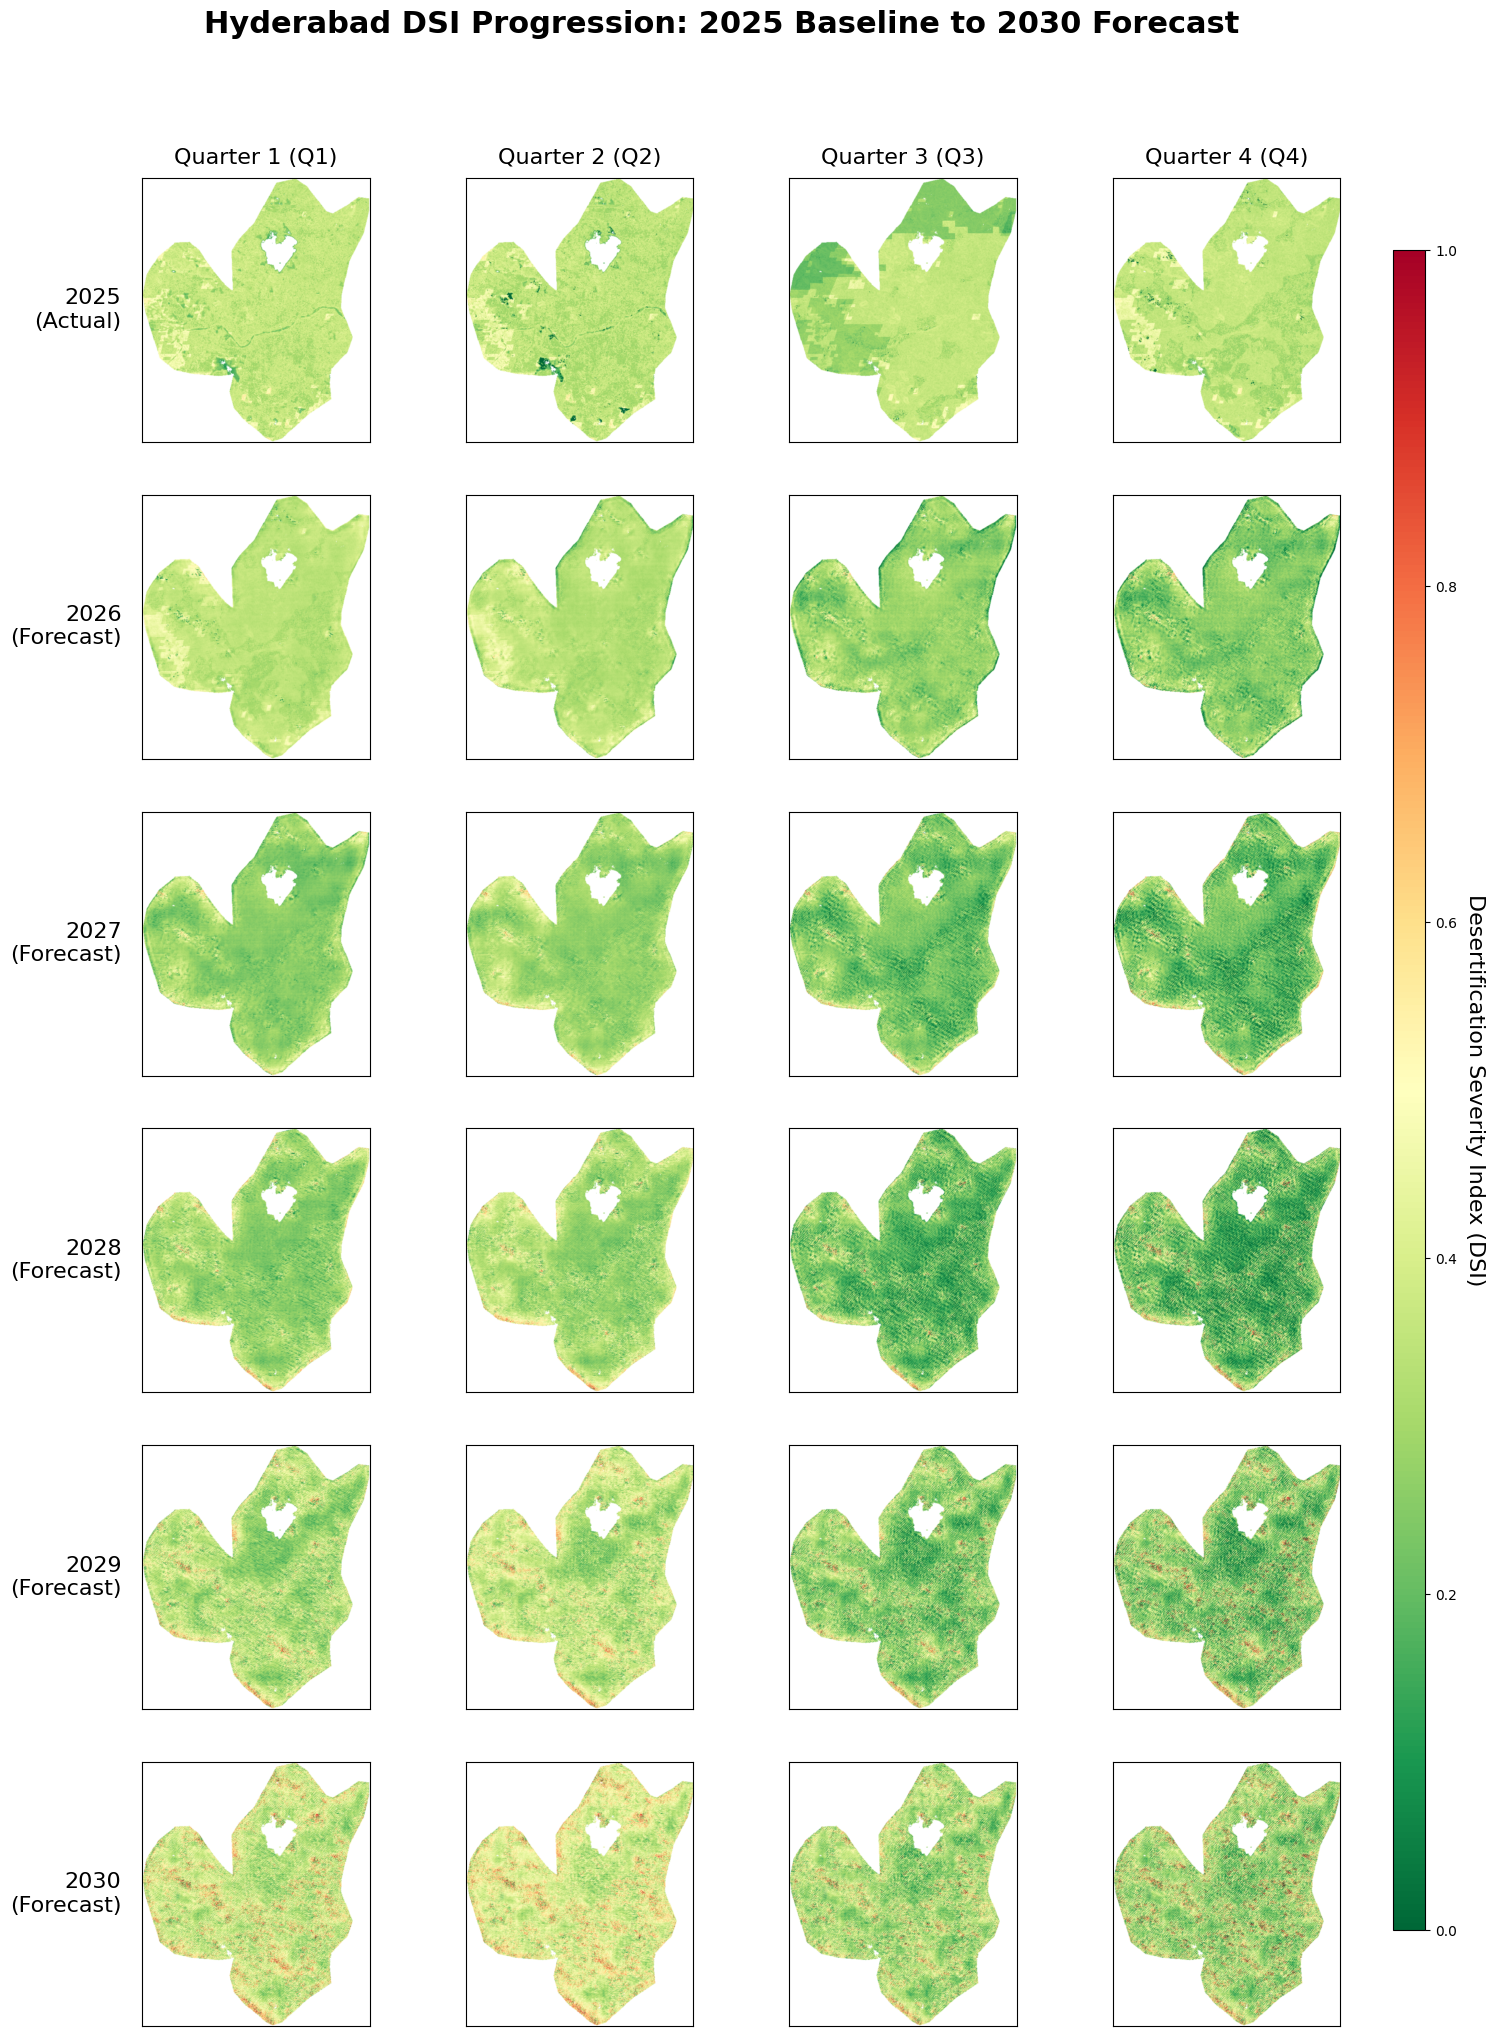

In [15]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_Progression_Grid.png"

# 1. Load the built-in RdYlGn_r colormap
# We copy it so we can safely modify how it handles masked (bad) data
cmap = plt.get_cmap('RdYlGn_r').copy()
cmap.set_bad(color='white')

# --- CREATE THE MASTER MASK ---
# We read the first band of the 2025 data to find out EXACTLY where the background is.
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0

    # This creates a boolean array that is True for outside areas.
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# 2. Set up the grid
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 24))
fig.patch.set_facecolor('white')

years = [2025, 2026, 2027, 2028, 2029, 2030]
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
last_im = None

# 3. Iterate and plot
for i, year in enumerate(years):
    for j in range(4):
        ax = axes[i, j]
        ax.set_facecolor('white')

        try:
            if year == 2025:
                with rasterio.open(INPUT_TIFF) as src:
                    dsi_data = src.read(j + 1)
            else:
                band_idx = (year - 2026) * 4 + j + 1
                with rasterio.open(OUTPUT_TIFF) as src:
                    dsi_data = src.read(band_idx)

            # --- APPLY THE MASTER MASK ---
            masked_dsi_data = np.ma.masked_where(master_mask, dsi_data)

            # Plot using the new RdYlGn_r colormap
            im = ax.imshow(masked_dsi_data, cmap=cmap, vmin=0, vmax=1, interpolation='bilinear')
            last_im = im

        except Exception as e:
            print(f"Warning: Could not load data for {year} Q{j+1}. {e}")
            ax.text(0.5, 0.5, 'Missing', ha='center', va='center', color='gray')

        # --- FORMATTING ---
        ax.set_xticks([])
        ax.set_yticks([])

        if i == 0:
            ax.set_title(f"Quarter {j+1} ({quarters[j]})", fontsize=16, pad=10)

        if j == 0:
            label = f"{year}\n(Actual)" if year == 2025 else f"{year}\n(Forecast)"
            ax.set_ylabel(label, fontsize=16, labelpad=15, rotation=0, ha='right', va='center')

# 4. Colorbar and Title
if last_im:
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(last_im, cax=cbar_ax)
    cbar.set_label('Desertification Severity Index (DSI)', fontsize=16, rotation=270, labelpad=20)

fig.suptitle("Hyderabad DSI Progression: 2025 Baseline to 2030 Forecast", fontsize=22, y=0.95, weight='bold')

# --- SAVE THE FIGURE ---
print(f"[*] Saving high-resolution grid to: {SAVE_PATH}")
plt.savefig(SAVE_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
import io

# --- 1. CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_GIF_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_Forecast.gif"

# We will lock the color scale so the animation doesn't "flicker" as max values change
VMIN = 0.1
VMAX = 1.0  # Based on your hexbin plots, 0.6 is a great upper bound for high contrast

# --- 2. CREATE THE MASTER MASK ---
print("[*] Loading master mask...")
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 3. PREPARE TO GENERATE FRAMES ---
years = [2025, 2026, 2027, 2028, 2029, 2030]
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
frames = []

print("[*] Rendering frames (this may take a minute)...")

# Use reversed Red-Yellow-Green (Green=Good/Low DSI, Red=Bad/High DSI)
cmap = plt.get_cmap('RdYlGn_r').copy()
cmap.set_bad(color='white')

for year in years:
    for j in range(4):
        quarter = quarters[j]

        # Load the right band
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Apply mask
        masked_map = np.ma.masked_where(master_mask, band_data)

        # --- DRAW THE FRAME ---
        fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

        # Plot the map
        im = ax.imshow(masked_map, cmap=cmap, vmin=VMIN, vmax=VMAX)
        ax.axis('off')

        # Add a sleek, bold title indicating the time step
        phase = "(Baseline)" if year == 2025 else "(Forecast)"
        ax.set_title(f"Desertification Sensitivity: {year} {quarter}\n{phase}",
                     fontsize=18, fontweight='bold', pad=15)

        # Add colorbar only once (it stays static across the GIF)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, orientation='horizontal')
        cbar.set_label('Predicted DSI Risk', fontsize=12, fontweight='bold')

        # Save the frame to a temporary memory buffer instead of cluttering your hard drive
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
        buf.seek(0)

        # Read the buffer into imageio and append to frames list
        frames.append(imageio.imread(buf))

        # Close the plot to save RAM
        plt.close(fig)

        print(f"    - Rendered {year} {quarter}")

# --- 4. STITCH AND SAVE THE GIF ---
print("\n[*] Stitching frames into animated GIF...")
# duration=0.5 means each frame stays on screen for half a second (2 frames per second)
imageio.mimsave(SAVE_GIF_PATH, frames, format='GIF', duration=800)

print(f"[*] SUCCESS! GIF saved to: {SAVE_GIF_PATH}")

[*] Loading master mask...
[*] Rendering frames (this may take a minute)...


/tmp/ipykernel_202/3271112507.py:76: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(buf))


    - Rendered 2025 Q1
    - Rendered 2025 Q2
    - Rendered 2025 Q3
    - Rendered 2025 Q4
    - Rendered 2026 Q1
    - Rendered 2026 Q2
    - Rendered 2026 Q3
    - Rendered 2026 Q4
    - Rendered 2027 Q1
    - Rendered 2027 Q2
    - Rendered 2027 Q3
    - Rendered 2027 Q4
    - Rendered 2028 Q1
    - Rendered 2028 Q2
    - Rendered 2028 Q3
    - Rendered 2028 Q4
    - Rendered 2029 Q1
    - Rendered 2029 Q2
    - Rendered 2029 Q3
    - Rendered 2029 Q4
    - Rendered 2030 Q1
    - Rendered 2030 Q2
    - Rendered 2030 Q3
    - Rendered 2030 Q4

[*] Stitching frames into animated GIF...
[*] SUCCESS! GIF saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_Forecast.gif


[*] 6x4 Histogram Grid saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_Quarterly_Histograms_Grid.png


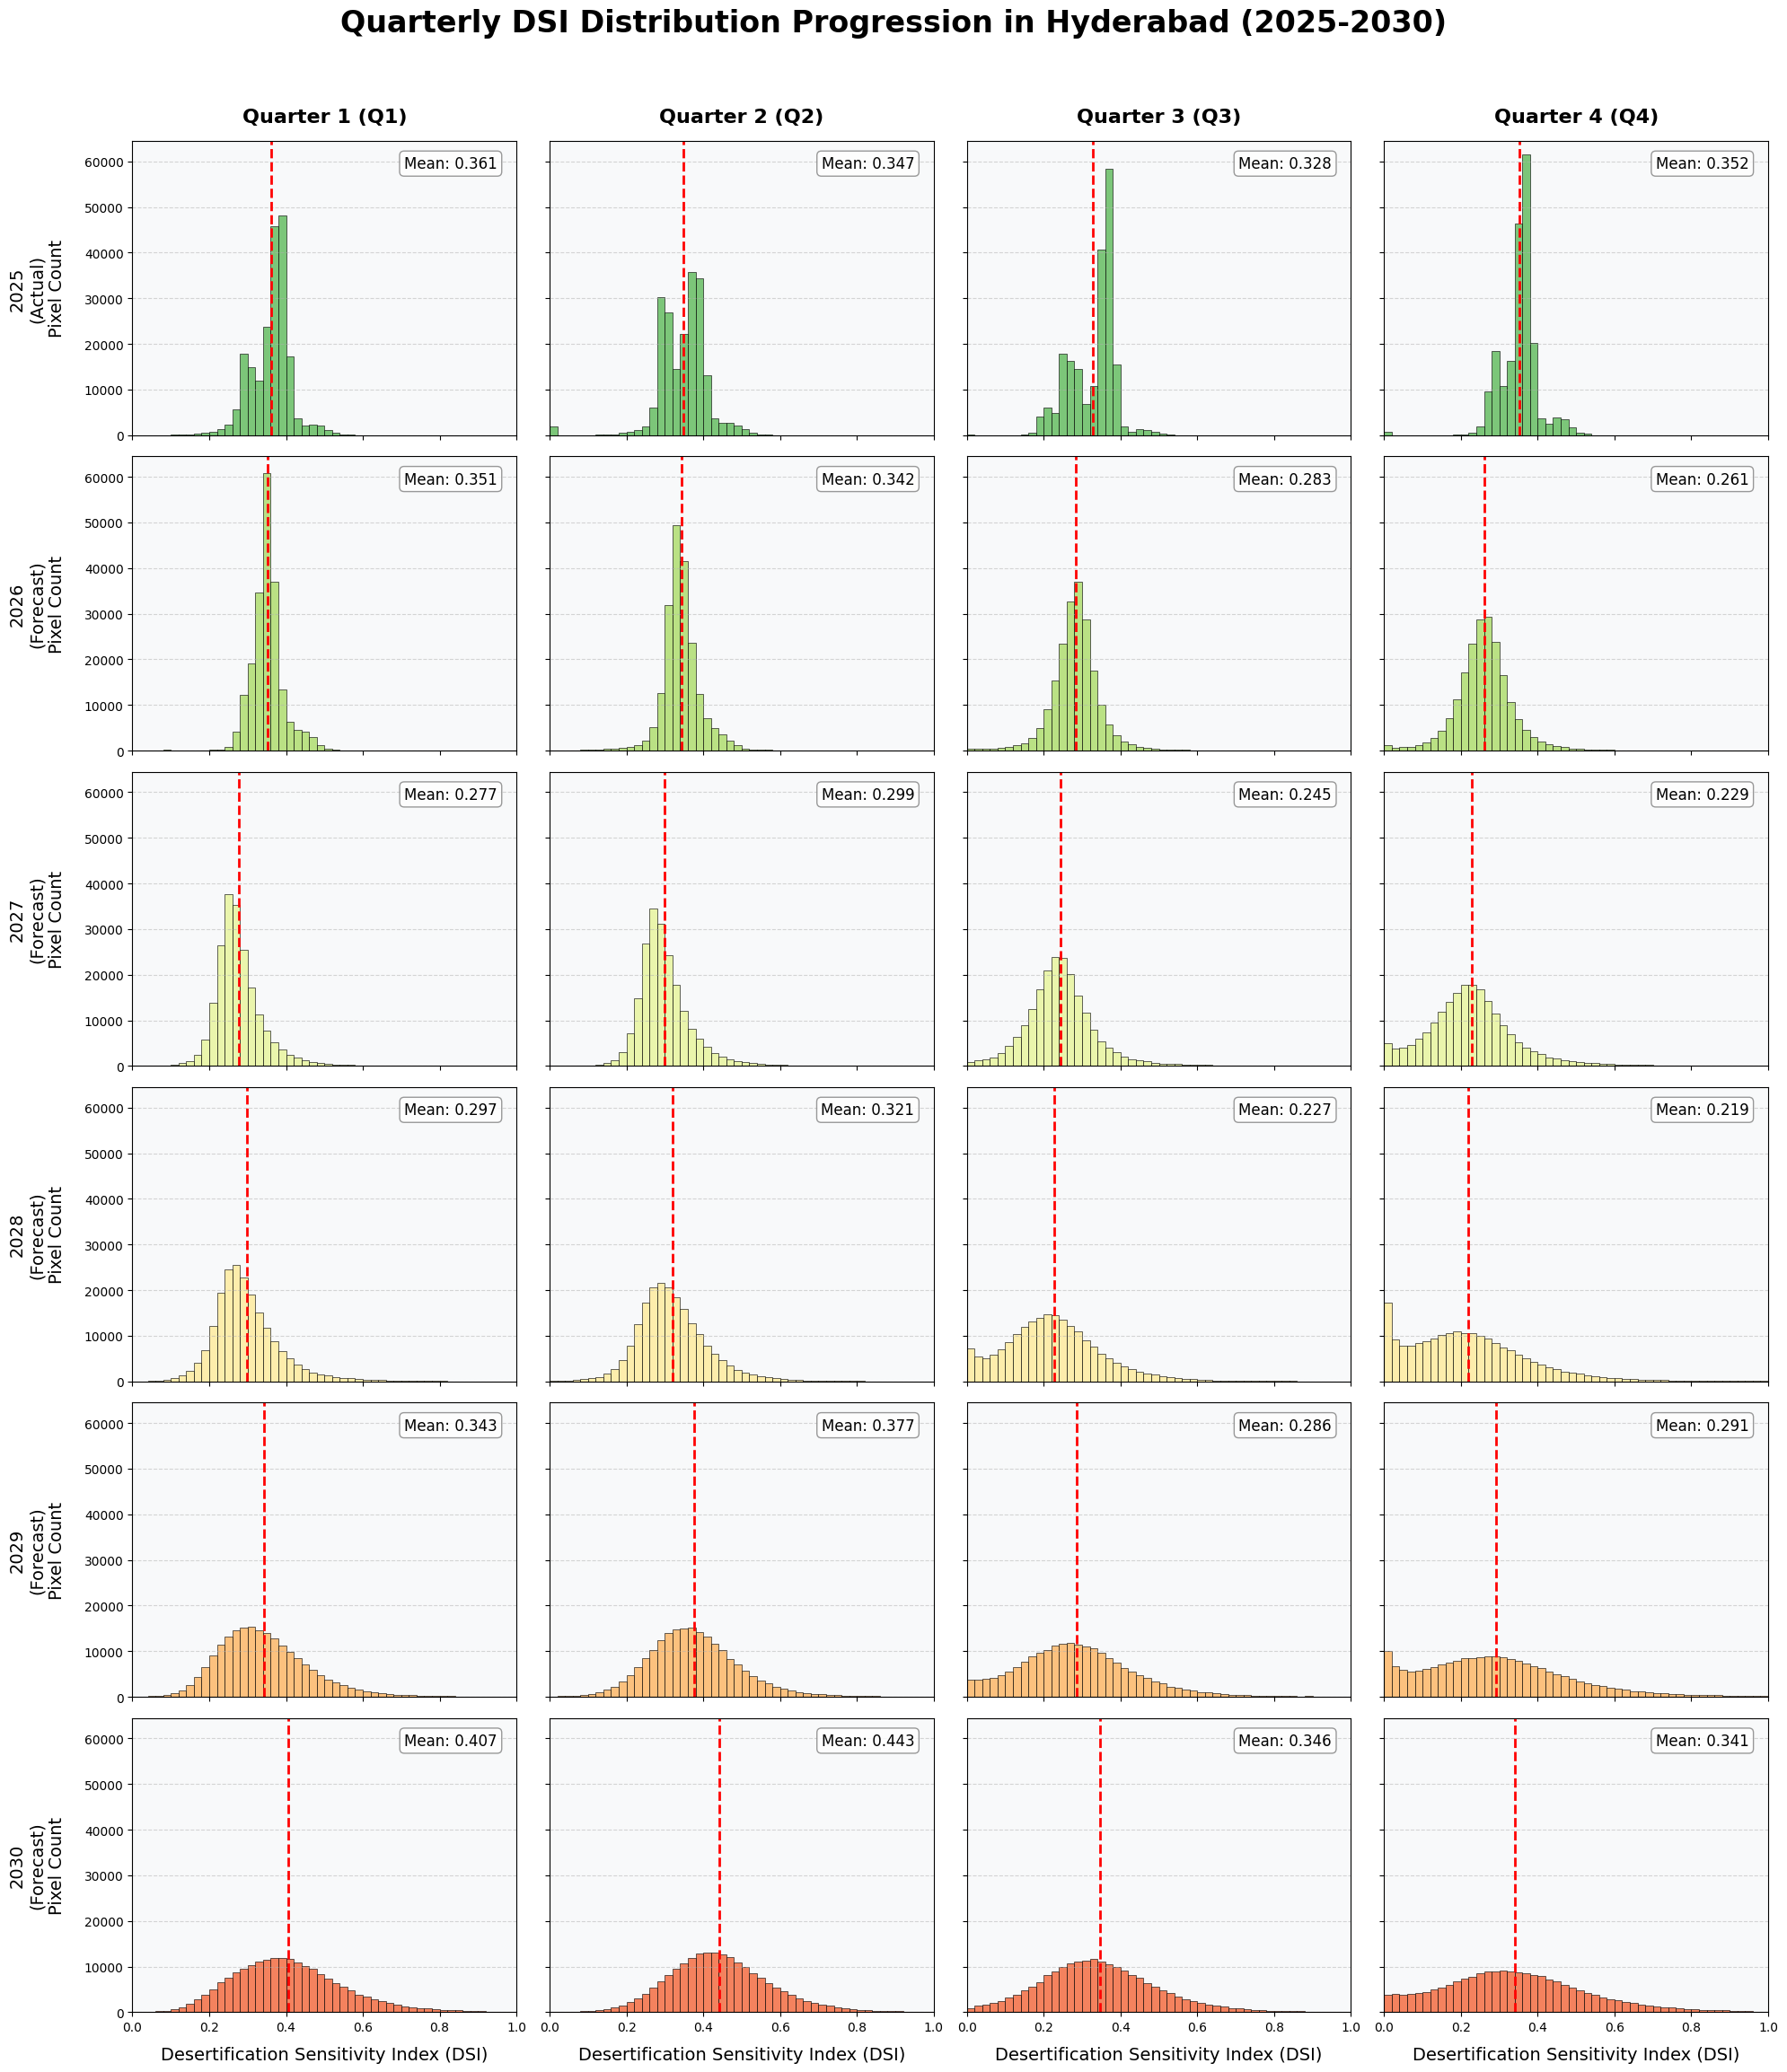

In [18]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_HIST_GRID_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Quarterly_Histograms_Grid.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. SET UP THE GRID ---
# sharex=True and sharey=True make the scales identical for perfect visual comparison
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 24), sharex=True, sharey=True)
fig.patch.set_facecolor('white')

years = [2025, 2026, 2027, 2028, 2029, 2030]
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# Generate a color for each year row so it's easy to track progression
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 6))

# --- 3. EXTRACT AND PLOT DATA ---
for i, year in enumerate(years):
    row_color = colors[i]

    for j in range(4):
        ax = axes[i, j]
        ax.set_facecolor('#f8f9fa') # Very light gray background for the plot area

        # Load the right band
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Mask and extract valid pixels
        masked_map = np.ma.masked_where(master_mask, band_data)
        valid_pixels = masked_map.compressed()

        # Plot the histogram
        ax.hist(valid_pixels, bins=50, range=(0, 1), color=row_color, alpha=0.85, edgecolor='black', linewidth=0.5)

        # Add a vertical dashed line for the mean
        mean_val = np.mean(valid_pixels)
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2)

        # Add text for the Mean value inside the plot
        ax.text(0.95, 0.95, f'Mean: {mean_val:.3f}', transform=ax.transAxes,
                fontsize=12, verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

        # --- FORMATTING ---
        ax.set_xlim(0, 1)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        # Add Column Titles (Quarters)
        if i == 0:
            ax.set_title(f"Quarter {j+1} ({quarters[j]})", fontsize=16, pad=15, fontweight='bold')

        # Add Row Labels (Years) to the first column
        if j == 0:
            label = f"{year}\n(Actual)" if year == 2025 else f"{year}\n(Forecast)"
            ax.set_ylabel(f"{label}\nPixel Count", fontsize=14, labelpad=15)

        # Add X-axis Labels to the bottom row
        if i == 5:
            ax.set_xlabel("Desertification Sensitivity Index (DSI)", fontsize=14, labelpad=10)

# --- 4. FINALIZE AND SAVE ---
fig.suptitle("Quarterly DSI Distribution Progression in Hyderabad (2025-2030)", fontsize=24, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(SAVE_HIST_GRID_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] 6x4 Histogram Grid saved to: {SAVE_HIST_GRID_PATH}")

plt.show()

[*] Pooled histogram saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_Annual_Pooled_Histograms.png


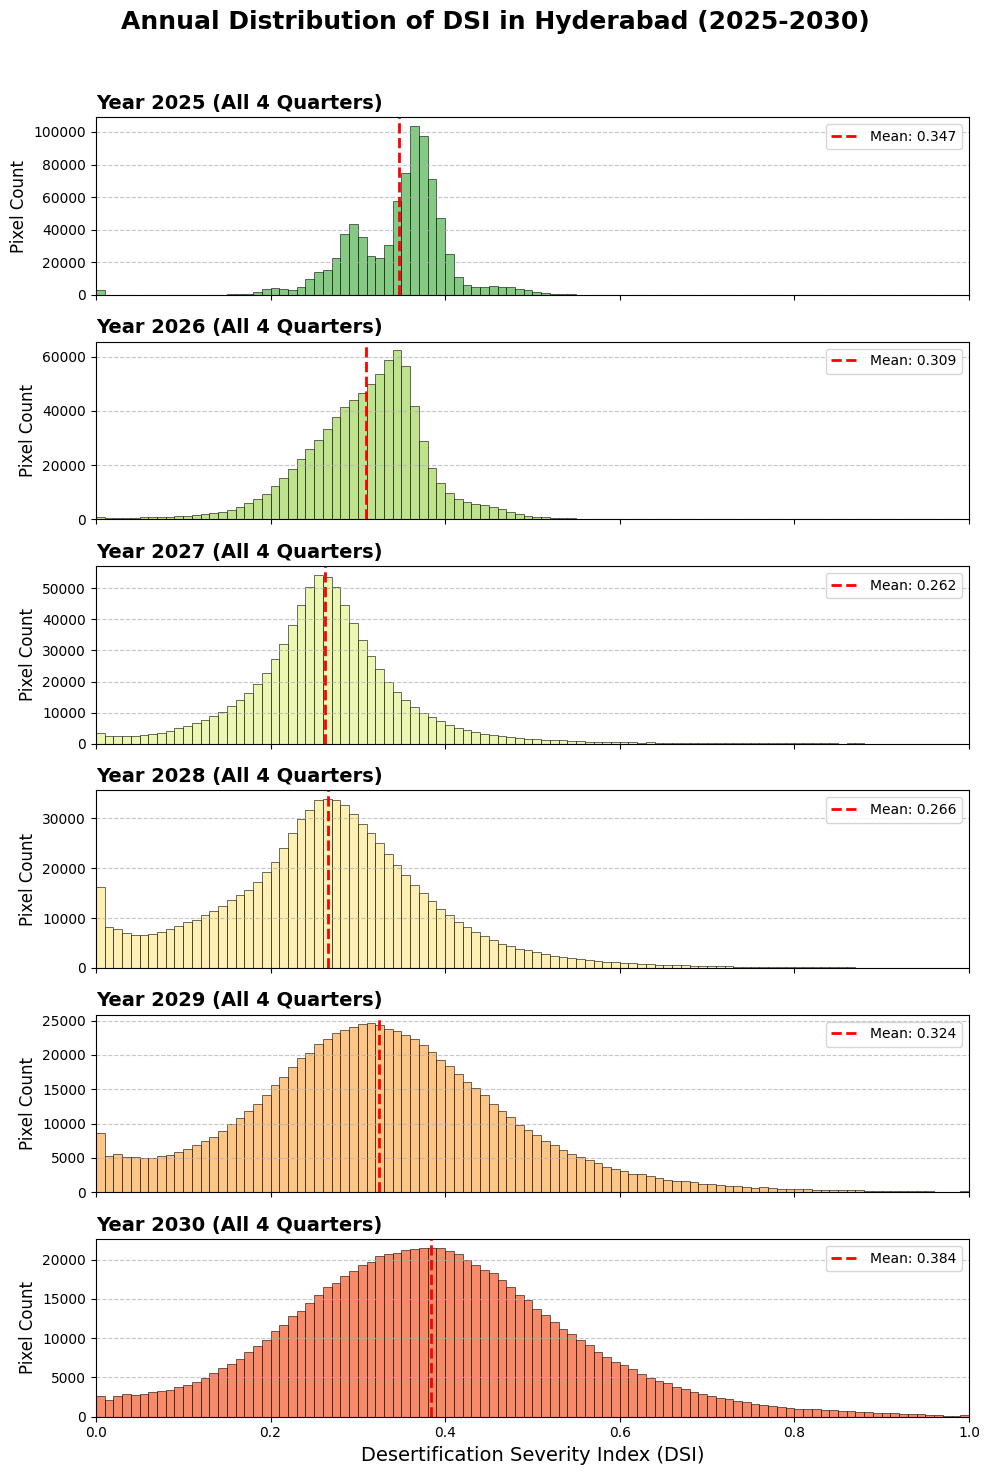

In [16]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_HIST_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Annual_Pooled_Histograms.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. EXTRACT AND POOL ANNUAL DATA ---
years = [2025, 2026, 2027, 2028, 2029, 2030]
annual_dsi_values = {}

for year in years:
    year_pixels = []

    # Fetch the 4 quarters for the given year
    for j in range(4):
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Mask out the background/NoData for this specific quarter
        masked_quarter_map = np.ma.masked_where(master_mask, band_data)

        # Flatten the 2D map into a 1D array of just the valid pixels
        valid_pixels = masked_quarter_map.compressed()
        year_pixels.append(valid_pixels)

    # Concatenate all 4 quarters into one giant list of pixels for the year
    annual_dsi_values[year] = np.concatenate(year_pixels)

# --- 3. PLOT THE HISTOGRAMS ---
# We will create 6 subplots stacked vertically (one for each year)
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10, 15), sharex=True)
fig.patch.set_facecolor('white')

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 6))

for i, year in enumerate(years):
    ax = axes[i]
    data = annual_dsi_values[year]

    # Plot histogram
    ax.hist(data, bins=100, range=(0, 1), color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)

    # Add a vertical dashed line for the mean DSI of that pooled data
    mean_val = np.mean(data)
    ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.3f}')

    # Formatting
    ax.set_ylabel("Pixel Count", fontsize=12)
    ax.set_title(f"Year {year} (All 4 Quarters)", loc='left', fontsize=14, fontweight='bold')
    ax.legend(loc="upper right")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Lock the x-axis from 0 to 1
    ax.set_xlim(0, 1)

# X-axis label
axes[-1].set_xlabel("Desertification Severity Index (DSI)", fontsize=14)

# Main Title
fig.suptitle("Annual Distribution of DSI in Hyderabad (2025-2030)", fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(SAVE_HIST_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] Pooled histogram saved to: {SAVE_HIST_PATH}")

plt.show()

[*] Stacked Bar Chart saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_Severity_Stacked_Bar.png


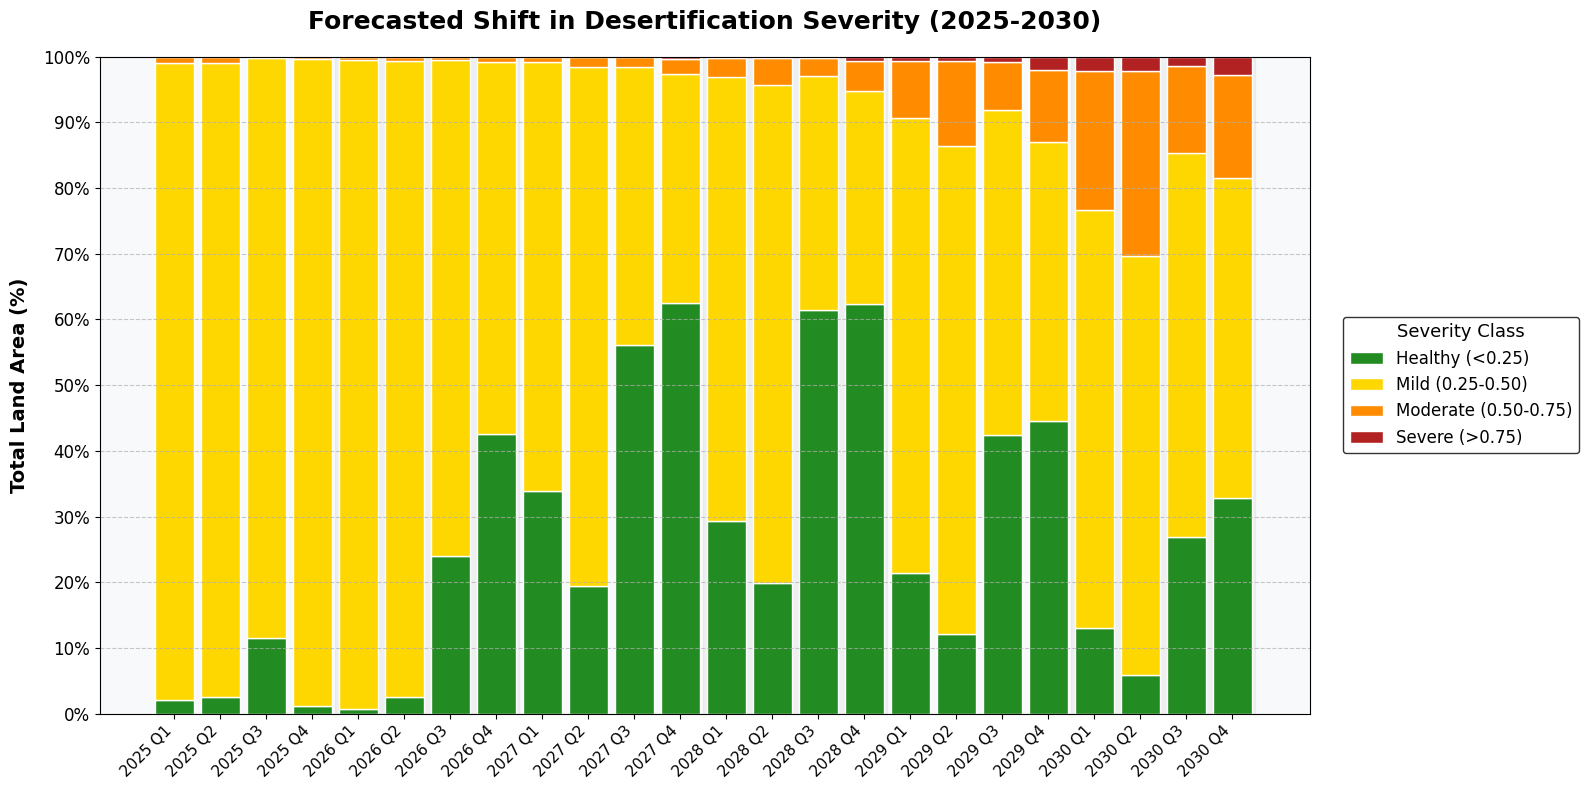

In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_CHART_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Severity_Stacked_Bar.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. DEFINE SEVERITY CLASSES ---
# Adjust these thresholds based on your specific DSI definitions
classes = {
    "Healthy (<0.25)": {"range": (0.0, 0.25), "color": "forestgreen"},
    "Mild (0.25-0.50)": {"range": (0.25, 0.50), "color": "gold"},
    "Moderate (0.50-0.75)": {"range": (0.50, 0.75), "color": "darkorange"},
    "Severe (>0.75)": {"range": (0.75, 1.01), "color": "firebrick"} # 1.01 to include exactly 1.0
}

years = [2025, 2026, 2027, 2028, 2029, 2030]
x_labels = []

# Initialize arrays to hold the percentage data for each class
class_percentages = {key: [] for key in classes.keys()}

# --- 3. EXTRACT AND CATEGORIZE DATA ---
for year in years:
    for j in range(4):
        x_labels.append(f"{year} Q{j+1}")

        # Load the right band
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Mask and extract valid pixels
        masked_map = np.ma.masked_where(master_mask, band_data)
        valid_pixels = masked_map.compressed()
        total_valid = len(valid_pixels)

        # Calculate the percentage of land falling into each severity class
        for class_name, info in classes.items():
            lower, upper = info["range"]
            # Count pixels within this specific range
            count = np.sum((valid_pixels >= lower) & (valid_pixels < upper))
            percentage = (count / total_valid) * 100
            class_percentages[class_name].append(percentage)

# --- 4. PLOT THE STACKED BAR CHART ---
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

# Track the bottom position for stacking
bottoms = np.zeros(len(x_labels))
x_indices = np.arange(len(x_labels))

# Plot each class layer by layer
for class_name, info in classes.items():
    percentages = np.array(class_percentages[class_name])
    ax.bar(x_indices, percentages, bottom=bottoms, color=info["color"],
           edgecolor='white', width=0.85, label=class_name)
    bottoms += percentages # Move the starting point up for the next bar

# --- 5. FORMATTING ---
ax.set_xticks(x_indices)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in np.arange(0, 101, 10)], fontsize=12)

ax.set_ylabel("Total Land Area (%)", fontsize=14, fontweight='bold', labelpad=10)
ax.set_title("Forecasted Shift in Desertification Severity (2025-2030)", fontsize=18, fontweight='bold', pad=20)

# Add a clean grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Format the legend to sit outside the chart on the right
ax.legend(title="Severity Class", title_fontsize='13', fontsize='12',
          loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, edgecolor='black')

# Add subtle background shading to separate years visually
for i in range(4, 24, 8):
    ax.axvspan(i-0.5, i+3.5, color='gray', alpha=0.08, zorder=0)

plt.tight_layout()
plt.savefig(SAVE_CHART_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] Stacked Bar Chart saved to: {SAVE_CHART_PATH}")

plt.show()

[*] Anomaly Map saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_Anomaly_Map.png


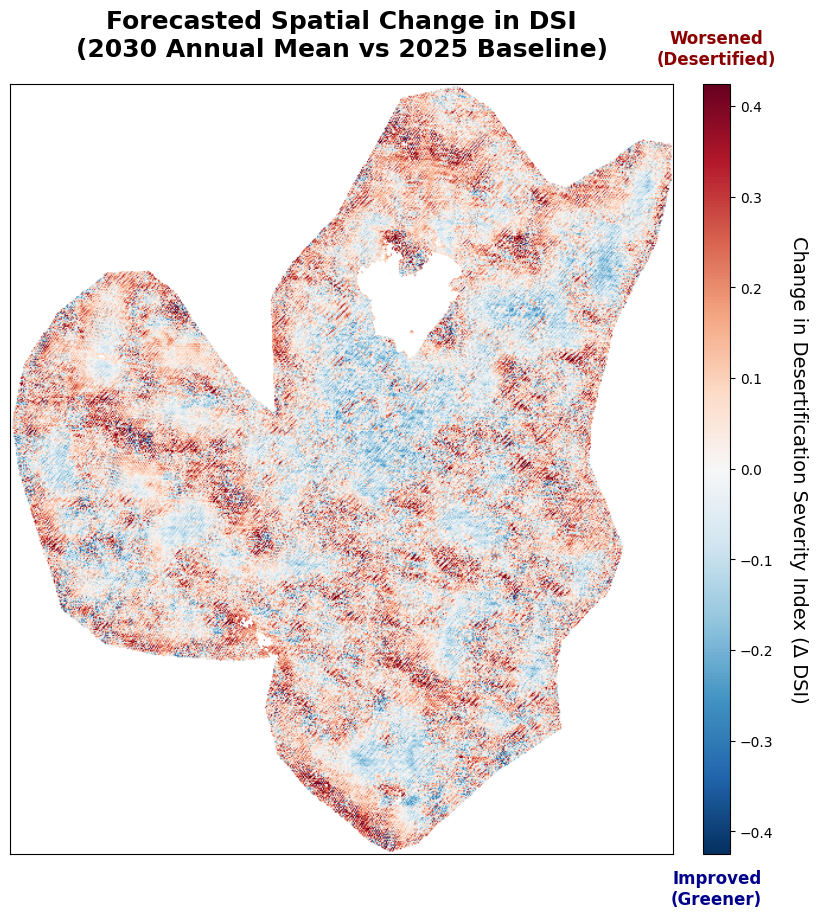

In [11]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_ANOMALY_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_Anomaly_Map.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. CALCULATE ANNUAL MEANS ---
# Load 2025 (Bands 1 to 4) and calculate the average
with rasterio.open(INPUT_TIFF) as src:
    data_2025 = np.mean([src.read(i) for i in range(1, 5)], axis=0)

# Load 2030 (Bands 17 to 20) and calculate the average
# Band index math: (2030 - 2026) * 4 = 16. So bands 17, 18, 19, 20.
with rasterio.open(OUTPUT_TIFF) as src:
    data_2030 = np.mean([src.read(i) for i in range(17, 21)], axis=0)

# --- 3. CALCULATE THE DIFFERENCE (ANOMALY) ---
# Positive value = DSI increased (worsened / more desertified)
# Negative value = DSI decreased (improved / greener)
dsi_change = data_2030 - data_2025

# Apply the master mask to the difference map
masked_change = np.ma.masked_where(master_mask, dsi_change)

# --- 4. PLOT THE ANOMALY MAP ---
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Set up the Diverging Colormap (Blue = Good/Negative Change, Red = Bad/Positive Change)
cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad(color='white')

# Ensure the color scale is perfectly centered on 0 (White)
valid_changes = masked_change.compressed()
limit = np.percentile(np.abs(valid_changes), 99)

# Plot the map
im = ax.imshow(masked_change, cmap=cmap, vmin=-limit, vmax=limit, interpolation='bilinear')

# Remove axis ticks for a clean look
ax.set_xticks([])
ax.set_yticks([])

# --- 5. ADD COLORBAR (Vertical on the Right) ---
# This perfectly aligns the colorbar height with the image height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.3)

cbar = fig.colorbar(im, cax=cax, orientation='vertical')
cbar.set_label('Change in Desertification Severity Index (\u0394 DSI)', fontsize=14, rotation=270, labelpad=25)

# Add text annotations to the top and bottom of the colorbar
cbar.ax.text(0.5, -0.02, 'Improved\n(Greener)', transform=cbar.ax.transAxes, ha='center', va='top', fontsize=12, color='darkblue', fontweight='bold')
cbar.ax.text(0.5, 1.02, 'Worsened\n(Desertified)', transform=cbar.ax.transAxes, ha='center', va='bottom', fontsize=12, color='darkred', fontweight='bold')

# Main Title
ax.set_title("Forecasted Spatial Change in DSI\n(2030 Annual Mean vs 2025 Baseline)", fontsize=18, fontweight='bold', pad=20)

# --- 6. SAVE AND SHOW ---
plt.savefig(SAVE_ANOMALY_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] Anomaly Map saved to: {SAVE_ANOMALY_PATH}")

plt.show()

[*] Seasonal Line Chart saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_Seasonal_Trends.png


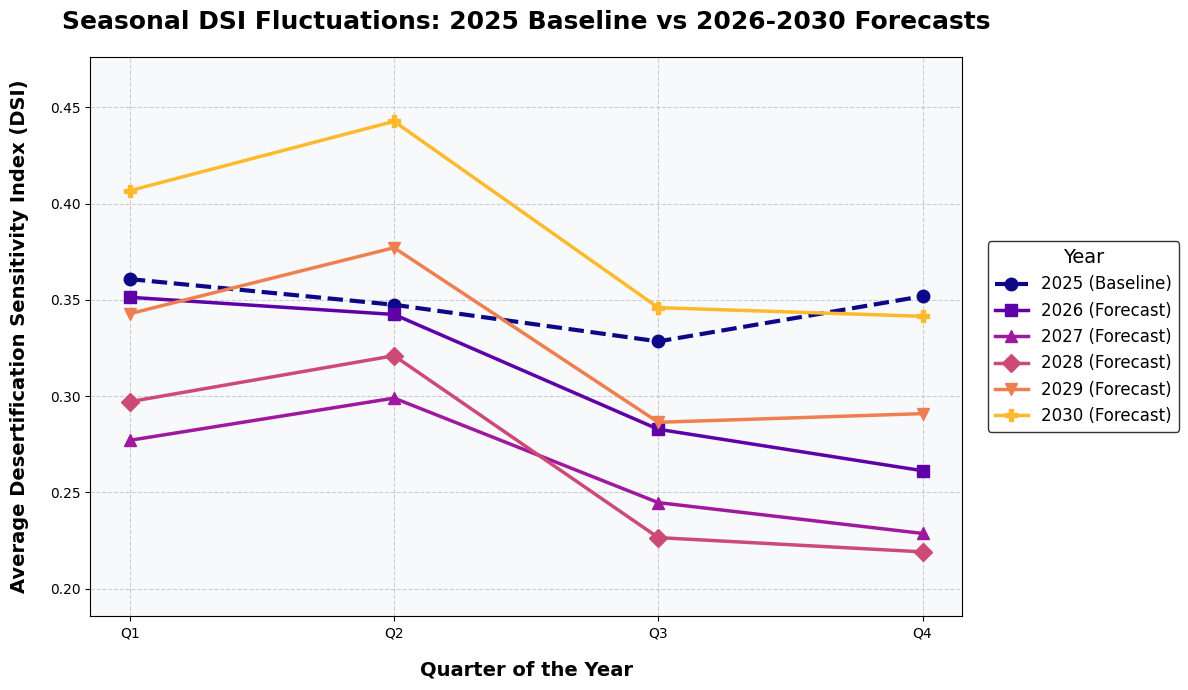

In [9]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_LINECHART_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Seasonal_Trends.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. EXTRACT QUARTERLY MEANS ---
years = [2025, 2026, 2027, 2028, 2029, 2030]
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# Dictionary to hold the 4 quarterly means for each year
seasonal_means = {year: [] for year in years}

for year in years:
    for j in range(4):
        # Load the right band
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Mask and calculate the mean for the entire valid land area
        masked_map = np.ma.masked_where(master_mask, band_data)
        quarter_mean = np.mean(masked_map)
        seasonal_means[year].append(quarter_mean)

# --- 3. PLOT THE MULTI-LINE CHART ---
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

# Use a colormap that transitions visually (e.g., cool to warm) to show progression over time
# We use plasma or a custom gradient so 2025 stands out from 2030
colors = plt.cm.plasma(np.linspace(0, 0.85, len(years)))
markers = ['o', 's', '^', 'D', 'v', 'P'] # Different markers for accessibility and clarity

for i, year in enumerate(years):
    # Plot the line for the year
    # We make 2025 (baseline) dashed and slightly thicker to stand out, and forecasts solid
    line_style = '--' if year == 2025 else '-'
    line_width = 3 if year == 2025 else 2.5

    ax.plot(quarters, seasonal_means[year], label=f"{year} {'(Baseline)' if year == 2025 else '(Forecast)'}",
            color=colors[i], marker=markers[i], linestyle=line_style, linewidth=line_width, markersize=9, zorder=3)

# --- 4. FORMATTING ---
ax.set_xlabel("Quarter of the Year", fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel("Average Desertification Sensitivity Index (DSI)", fontsize=14, fontweight='bold', labelpad=15)
ax.set_title("Seasonal DSI Fluctuations: 2025 Baseline vs 2026-2030 Forecasts", fontsize=18, fontweight='bold', pad=20)

# Add gridlines (put them behind the plotted lines using zorder)
ax.grid(axis='both', linestyle='--', alpha=0.6, zorder=0)

# Place the legend outside the plot to keep the lines unobstructed
ax.legend(title="Year", title_fontsize='14', fontsize='12',
          loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, edgecolor='black')

# Slightly expand the Y-axis limits so the lines don't hit the absolute top or bottom of the frame
all_means = [val for means in seasonal_means.values() for val in means]
y_min, y_max = min(all_means), max(all_means)
padding = (y_max - y_min) * 0.15
ax.set_ylim(y_min - padding, y_max + padding)

# --- 5. SAVE AND SHOW ---
plt.tight_layout()
plt.savefig(SAVE_LINECHART_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] Seasonal Line Chart saved to: {SAVE_LINECHART_PATH}")

plt.show()

[*] Time-Series Chart saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_TimeSeries_Trend.png


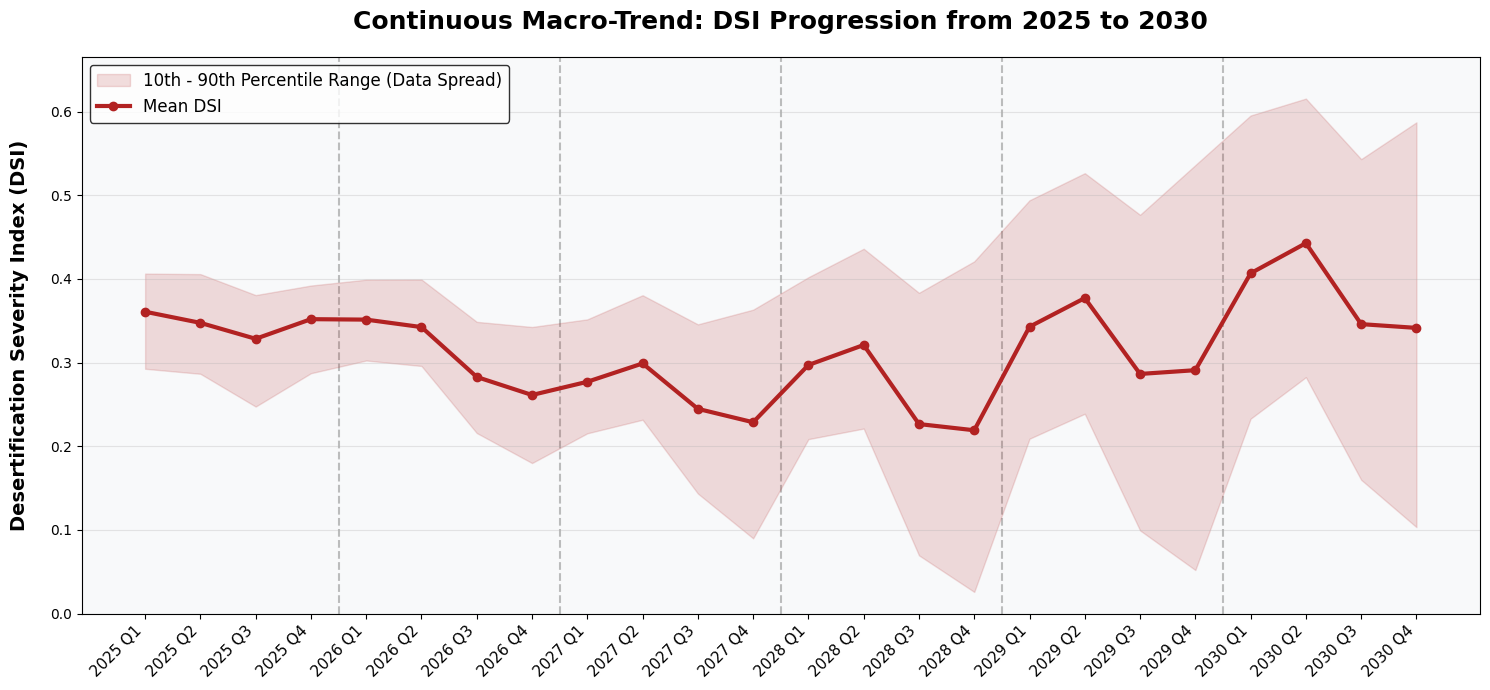

In [10]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_TS_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_TimeSeries_Trend.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. EXTRACT CONTINUOUS DATA ---
years = [2025, 2026, 2027, 2028, 2029, 2030]
x_labels = []
means = []
p10s = []
p90s = []

# Loop through every single quarter sequentially (24 total steps)
for year in years:
    for j in range(4):
        x_labels.append(f"{year} Q{j+1}")

        # Load the right band
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Mask and extract valid pixels
        masked_map = np.ma.masked_where(master_mask, band_data)
        valid_pixels = masked_map.compressed()

        # Calculate statistical metrics for the ribbon
        means.append(np.mean(valid_pixels))
        p10s.append(np.percentile(valid_pixels, 10))
        p90s.append(np.percentile(valid_pixels, 90))

# Convert to numpy arrays for plotting
x = np.arange(len(x_labels))
means = np.array(means)
p10s = np.array(p10s)
p90s = np.array(p90s)

# --- 3. PLOT THE TIME-SERIES WITH RIBBON ---
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

# Plot the shaded ribbon (10th to 90th percentile)
ax.fill_between(x, p10s, p90s, color='firebrick', alpha=0.15,
                label='10th - 90th Percentile Range (Data Spread)', zorder=1)

# Plot the solid Mean line
ax.plot(x, means, color='firebrick', linewidth=3, marker='o', markersize=6,
        label='Mean DSI', zorder=2)

# --- 4. FORMATTING ---
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Desertification Severity Index (DSI)", fontsize=14, fontweight='bold', labelpad=15)
ax.set_title("Continuous Macro-Trend: DSI Progression from 2025 to 2030", fontsize=18, fontweight='bold', pad=20)

# Add vertical dashed lines to separate the years cleanly
for i in range(3, 23, 4):
    ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.5, zorder=0)

# Y-axis bounds (locked between 0 and 1, or dynamic based on your data)
ax.set_ylim(max(0, min(p10s) - 0.05), min(1, max(p90s) + 0.05))

# Add a clean grid
ax.grid(axis='y', linestyle='-', alpha=0.3, zorder=0)

# Legend
ax.legend(loc='upper left', fontsize='12', frameon=True, edgecolor='black', facecolor='white')

# --- 5. SAVE AND SHOW ---
plt.tight_layout()
plt.savefig(SAVE_TS_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] Time-Series Chart saved to: {SAVE_TS_PATH}")

plt.show()

[*] Standard Deviation Chart saved to: /content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_StdDev_Trend.png


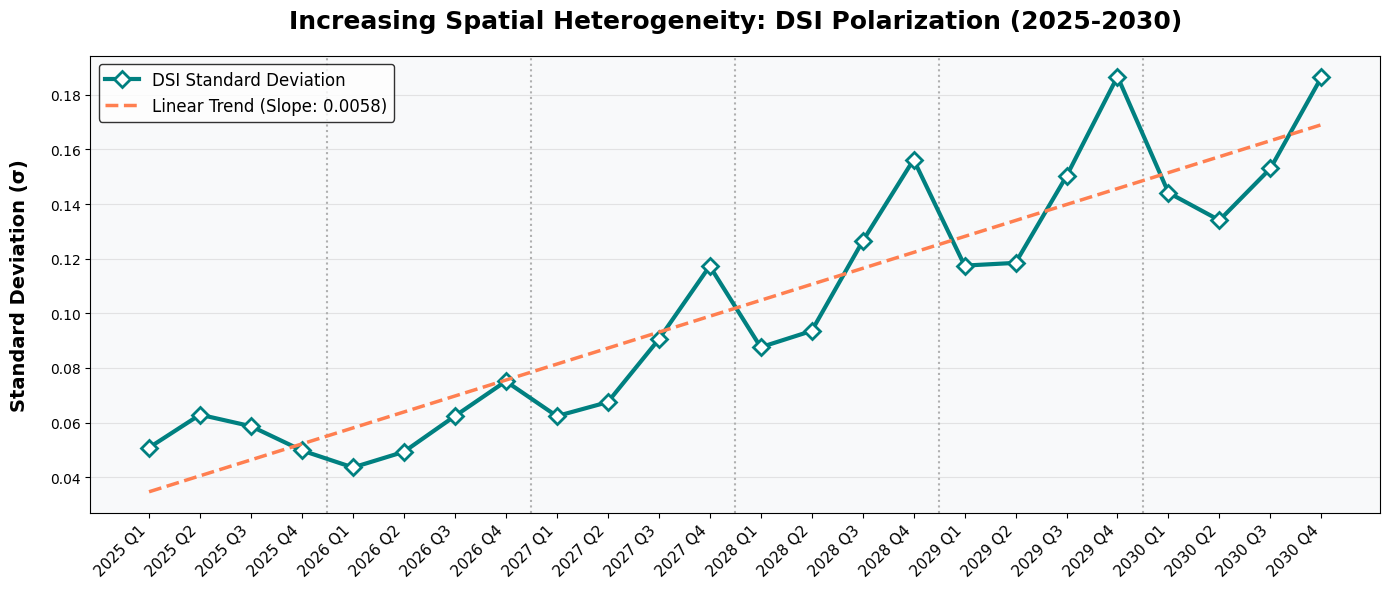

In [12]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
INPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_ModelB_Inputs_2025.tif"
OUTPUT_TIFF = "/content/drive/MyDrive/FYP_Inference/Hyderabad_Predicted_2026_to_2030_Smooth.tif"
SAVE_STD_PATH = "/content/drive/MyDrive/FYP_Inference/Hyderabad_DSI_StdDev_Trend.png"

# --- 1. CREATE THE MASTER MASK ---
with rasterio.open(INPUT_TIFF) as src:
    base_data = src.read(1)
    nodata_val = src.nodata if src.nodata is not None else 0.0
    if np.isnan(nodata_val):
        master_mask = np.isnan(base_data) | (base_data == 0.0)
    else:
        master_mask = (base_data == nodata_val) | np.isnan(base_data) | (base_data == 0.0)

# --- 2. EXTRACT STANDARD DEVIATION DATA ---
years = [2025, 2026, 2027, 2028, 2029, 2030]
x_labels = []
std_devs = []

for year in years:
    for j in range(4):
        x_labels.append(f"{year} Q{j+1}")

        # Load the right band
        if year == 2025:
            with rasterio.open(INPUT_TIFF) as src:
                band_data = src.read(j + 1)
        else:
            band_idx = (year - 2026) * 4 + j + 1
            with rasterio.open(OUTPUT_TIFF) as src:
                band_data = src.read(band_idx)

        # Mask and extract valid pixels
        masked_map = np.ma.masked_where(master_mask, band_data)
        valid_pixels = masked_map.compressed()

        # Calculate the Standard Deviation
        std_devs.append(np.std(valid_pixels))

# Convert to numpy arrays for plotting
x = np.arange(len(x_labels))
std_devs = np.array(std_devs)

# --- 3. PLOT THE CHART ---
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

# Plot the Std Dev line
# We use a distinct color (like dark purple or teal) to differentiate it from the DSI mean charts
ax.plot(x, std_devs, color='teal', linewidth=3, marker='D', markersize=8,
        markerfacecolor='white', markeredgewidth=2, label='DSI Standard Deviation')

# Add a linear trendline to emphasize the upward trajectory
z = np.polyfit(x, std_devs, 1)
p = np.poly1d(z)
ax.plot(x, p(x), color='coral', linestyle='--', linewidth=2.5,
        label=f'Linear Trend (Slope: {z[0]:.4f})')

# --- 4. FORMATTING ---
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Standard Deviation (\u03C3)", fontsize=14, fontweight='bold', labelpad=15)
ax.set_title("Increasing Spatial Heterogeneity: DSI Polarization (2025-2030)", fontsize=18, fontweight='bold', pad=20)

# Add vertical dashed lines to separate the years cleanly
for i in range(3, 23, 4):
    ax.axvline(i + 0.5, color='gray', linestyle=':', alpha=0.6, zorder=0)

# Add a clean grid
ax.grid(axis='y', linestyle='-', alpha=0.3, zorder=0)

# Legend
ax.legend(loc='upper left', fontsize='12', frameon=True, edgecolor='black', facecolor='white')

# --- 5. SAVE AND SHOW ---
plt.tight_layout()
plt.savefig(SAVE_STD_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"[*] Standard Deviation Chart saved to: {SAVE_STD_PATH}")

plt.show()